In [1]:
import pandas as pd
import random

real_news = [
    "Government launches new healthcare program",
    "Scientists discover water on Mars",
    "New technology improves battery life",
    "Education reforms approved by parliament",
    "Economic growth increases this year"
]

fake_news = [
    "Aliens invade Earth secretly",
    "Man flies using homemade wings",
    "Time machine discovered in garage",
    "Ghost seen in shopping mall",
    "Magic potion cures all diseases"
]

data = []

for _ in range(100):
  data.append([random.choice(real_news), "Real"])
  data.append([random.choice(fake_news), "Fake"])

df = pd.DataFrame(data, columns=["text", "label"])
df.to_csv("/content/fake_news_dataset.csv", index=False)

print("Dataset created")

Dataset created


In [2]:
import re
import nltk
import joblib
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [3]:
df = pd.read_csv("/content/fake_news_dataset.csv")

In [4]:
df

,text,label
0,Government launches new healthcare program,Real
1,Magic potion cures all diseases,Fake
2,New technology improves battery life,Real
3,Magic potion cures all diseases,Fake
4,Economic growth increases this year,Real
...,...,...
195,Aliens invade Earth secretly,Fake
196,Economic growth increases this year,Real
197,Man flies using homemade wings,Fake
198,Government launches new healthcare program,Real


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    200 non-null    object
 1   label   200 non-null    object
dtypes: object(2)
memory usage: 3.3+ KB


In [8]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
  text = text.lower()
  text = re.sub(r'[^a-zA-Z]', ' ', text)
  words = text.split()
  words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
  return " ".join(words)


df['clean_text'] = df['text'].apply(preprocess)


vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['clean_text'])
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


print("Accuracy : ", accuracy_score(y_test, y_pred))
print("\nClassification Report : ", classification_report(y_test,y_pred))
print("\nConfusion Matrix : ", confusion_matrix(y_test,y_pred))


joblib.dump(model, 'model.pk1')
joblib.dump(vectorizer, 'vectorizer.pk1')

print("Model Saved")


Accuracy :  1.0

Classification Report :                precision    recall  f1-score   support

        Fake       1.00      1.00      1.00        16
        Real       1.00      1.00      1.00        24

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40


Confusion Matrix :  [[16  0]
 [ 0 24]]
Model Saved


<Axes: >

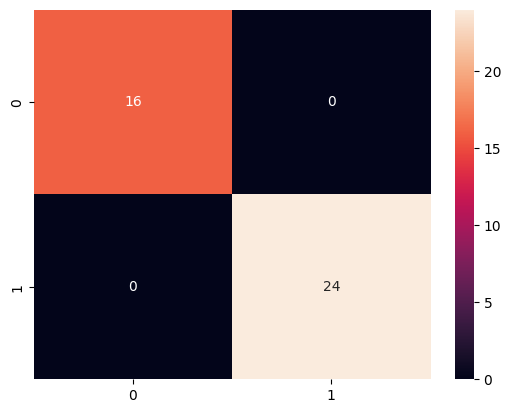

In [10]:
import seaborn as sns

sns.heatmap(confusion_matrix(y_test,y_pred),annot=True)